# 1. Project Introduction

## SwipeToHire — NLP-Based Resume Screening & Candidate Ranking System

### Project Overview

SwipeToHire is an end-to-end Data Science and Natural Language Processing (NLP) project designed to analyze candidate resumes against a given Job Description (JD).

The system processes resume and job description text, measures their relevance using NLP techniques, calculates match scores, and ranks candidates from most suitable to least suitable.

### Problem Statement

Recruiters often receive a large number of resumes for a single job opening. Manually reviewing every resume can be time-consuming and difficult, especially when the number of applicants is high.

SwipeToHire aims to simplify the initial resume screening process by automatically comparing candidate resumes with the requirements mentioned in a Job Description.

### Project Objective

The main objectives of this project are to:

* Analyze and preprocess resume text.
* Perform exploratory data analysis on the resume dataset.
* Convert resume and Job Description text into numerical features using TF-IDF.
* Measure Resume–Job Description similarity using Cosine Similarity.
* Calculate candidate match scores.
* Identify matching skills where appropriate.
* Rank candidates based on their relevance to the Job Description.
* Evaluate whether the ranking system produces meaningful results.
* Deploy the final NLP pipeline as an interactive web application.

### Project Approach

The project follows a complete Data Science and NLP workflow:

**Data Understanding → Data Cleaning → Exploratory Data Analysis → Text Preprocessing → TF-IDF Feature Extraction → Cosine Similarity → Match Score → Skills Matching → Candidate Ranking → Evaluation → Deployment**


# 2. Import Required Libraries

In this section, we import the Python libraries required for data manipulation, numerical operations, data visualization, and basic text processing.

These libraries will be used throughout the Data Science and NLP workflow of the SwipeToHire project.


In [1]:
# Data manipulation
import pandas as pd

# Numerical operations
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re

# 3. Data Understanding

In this section, we load the resume dataset and explore its basic structure.

The goal is to understand the number of rows and columns, available features, data types, missing values, and resume categories before performing any cleaning or preprocessing.


In [2]:
# Load the dataset
df = pd.read_csv("/content/Resume.csv")

# Display first 5 rows
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


## 3.1 Dataset Shape

The shape of the dataset shows the total number of rows and columns. Each row represents a resume, while the columns contain information associated with that resume.


In [3]:
# Check number of rows and columns
df.shape

(2484, 4)

## 3.2 Dataset Information

The `info()` function is used to inspect the dataset structure, including column names, data types, number of non-null values, and memory usage.

This helps us identify missing values and understand the type of data stored in each column before cleaning the dataset.


In [4]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


## 3.3 Statistical Summary

The `describe()` function provides a summary of the numerical columns in the dataset.

In this dataset, the main numerical column is the resume `ID`, so the summary is mainly useful for inspecting its basic statistics.


In [5]:
# Statistical summary
df.describe()

,ID
count,2.484000e+03
mean,3.182616e+07
std,2.145735e+07
min,3.547447e+06
25%,1.754430e+07
50%,2.521031e+07
75%,3.611444e+07
max,9.980612e+07


## 3.4 Dataset Columns

The dataset contains different columns representing the resume identifier, resume text, HTML-formatted resume content, and the corresponding job category.

Understanding the available columns helps us determine which features are useful for further analysis and NLP processing.


In [6]:
# Display column names
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

## 3.5 Resume Categories

The `Category` column represents the professional or job category associated with each resume.

In this section, we examine the number of unique categories and identify the different types of resumes available in the dataset. This helps us understand the diversity of the dataset before performing further analysis.


In [7]:
# Number of unique resume categories
df['Category'].nunique()

24

In [8]:
# Display all resume categories
df['Category'].unique()

array(['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)

## 3.6 Category Distribution

The number of resumes available in each professional category is examined using `value_counts()`.

This helps us understand how the resumes are distributed across the different job categories and whether some categories contain more resumes than others.


In [9]:
# Count resumes in each category
df['Category'].value_counts()

,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


# 4. Data Cleaning

Data cleaning is an important step before performing analysis or NLP processing.

In this section, we check the dataset for missing values, duplicate records, and unnecessary columns. Cleaning the dataset helps ensure that the later analysis and text processing are performed on reliable data.


## 4.1 Missing Values

Missing values can affect data analysis and NLP processing. Therefore, we first check whether any column contains null values.


In [10]:
# Check missing values
df.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


## 4.2 Duplicate Values

Duplicate records can cause repeated information in the dataset and may affect analysis.

Therefore, we check whether any complete duplicate rows are present in the dataset before continuing with further processing.


In [11]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

## 4.3 Removing Unnecessary Columns

The `ID` column is only a unique identifier and does not provide useful information for resume matching.

The `Resume_html` column contains the resume in HTML format, while the `Resume_str` column already provides the resume text required for NLP processing.

Therefore, these columns are removed to keep only the relevant data for analysis and text processing.


In [12]:
# Remove unnecessary columns
df = df.drop(columns=['ID', 'Resume_html'])

# Check updated dataset
df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


## 4.4 Final Clean Dataset

After checking for missing values, duplicate records, and unnecessary columns, the dataset is now ready for exploratory data analysis and NLP preprocessing.

The cleaned dataset contains only the resume text and its corresponding professional category.


In [13]:
# Check final cleaned dataset
df.shape

(2484, 2)

In [14]:
# Check final column names
df.columns

Index(['Resume_str', 'Category'], dtype='object')

# 5. Exploratory Data Analysis

Exploratory Data Analysis helps us understand the structure, patterns, and distribution of the resume dataset before applying NLP techniques.

In this section, we analyze resume categories, text length, and other useful characteristics of the resume data using visualizations.


## 5.1 Resume Category Distribution

The category distribution shows how many resumes are available for each professional category.

This helps us identify which categories contain more or fewer resumes and understand whether the dataset is balanced across different job domains.


In [15]:
# Count resumes in each category
category_counts = df['Category'].value_counts()

category_counts

,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


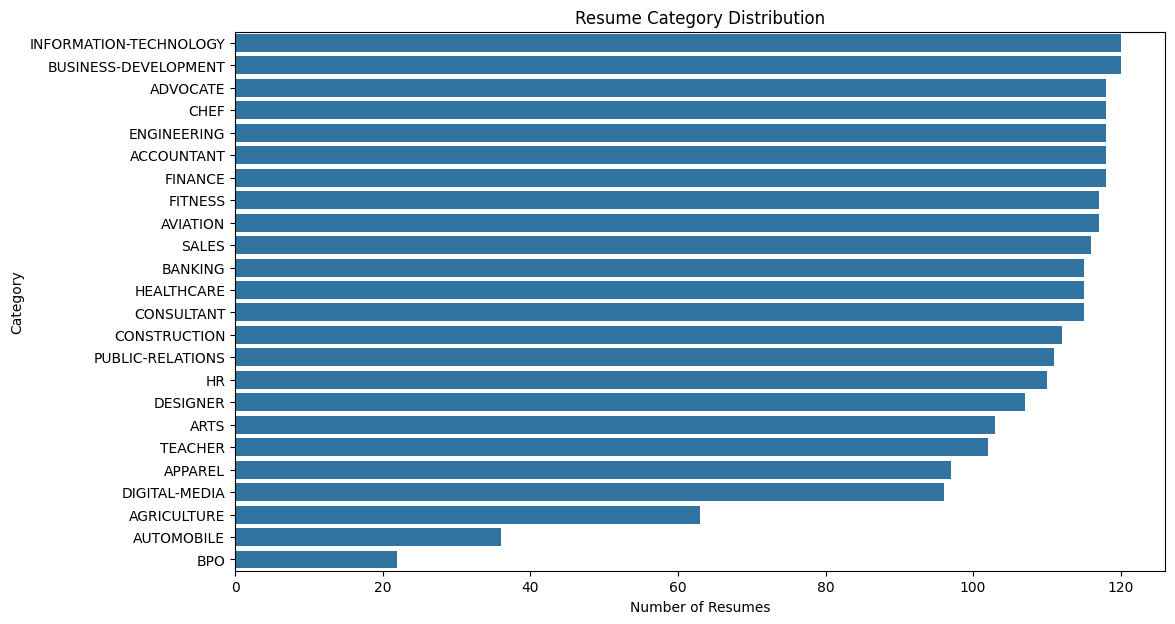

In [16]:
# Plot resume category distribution
plt.figure(figsize=(12, 7))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Resume Category Distribution")
plt.xlabel("Number of Resumes")
plt.ylabel("Category")

plt.show()

## 5.2 Resume Text Length Analysis

Resume text length can vary depending on the amount of information provided by each candidate.

In this section, we calculate the number of characters in each resume to understand the distribution and variation in resume length across the dataset.


In [17]:
# Calculate resume text length
df['Resume_Length'] = df['Resume_str'].apply(len)

# Display first 5 rows
df[['Resume_str', 'Resume_Length']].head()

,Resume_str,Resume_Length
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,5442
1,"HR SPECIALIST, US HR OPERATIONS ...",5572
2,HR DIRECTOR Summary Over 2...,7720
3,HR SPECIALIST Summary Dedica...,2855
4,HR MANAGER Skill Highlights ...,9172


### Resume Length Summary

The statistical summary of resume length helps us understand the average resume size, minimum and maximum text length, and the overall variation in resume content.


In [18]:
# Statistical summary of resume length
df['Resume_Length'].describe()

,Resume_Length
count,2484.000000
mean,6295.308776
std,2769.251458
min,21.000000
25%,5160.000000
50%,5886.500000
75%,7227.250000
max,38842.000000


### Resume Length Distribution

A histogram is used to visualize the distribution of resume text lengths.

This helps identify the most common range of resume lengths and whether unusually short or long resumes are present in the dataset.


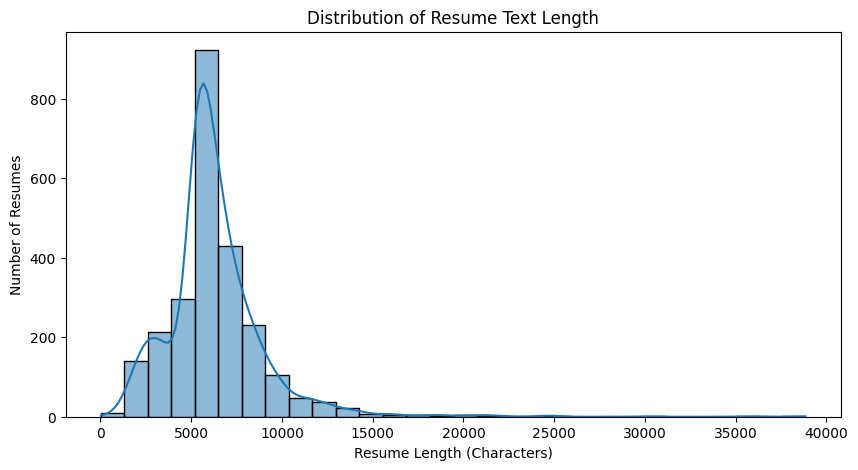

In [19]:
# Plot resume length distribution
plt.figure(figsize=(10, 5))

sns.histplot(df['Resume_Length'], bins=30, kde=True)

plt.title("Distribution of Resume Text Length")
plt.xlabel("Resume Length (Characters)")
plt.ylabel("Number of Resumes")

plt.show()

## 5.3 Average Resume Length by Category

Resume length may vary across different professional categories depending on the amount of experience, skills, and information typically included in the resumes.

In this analysis, we compare the average resume text length across the different job categories.


In [20]:
# Calculate average resume length by category
avg_length = df.groupby('Category')['Resume_Length'].mean().sort_values(ascending=False)

avg_length

,Resume_Length
Category,
BPO,7317.681818
INFORMATION-TECHNOLOGY,7227.550000
HEALTHCARE,6996.182609
PUBLIC-RELATIONS,6913.432432
CONSULTANT,6844.347826
HR,6760.763636
CONSTRUCTION,6618.455357
AGRICULTURE,6605.285714
ADVOCATE,6575.161017


### Average Resume Length by Category Visualization

A horizontal bar chart is used to compare the average resume text length across professional categories.

This provides a clear view of which categories tend to contain longer or shorter resume text on average.


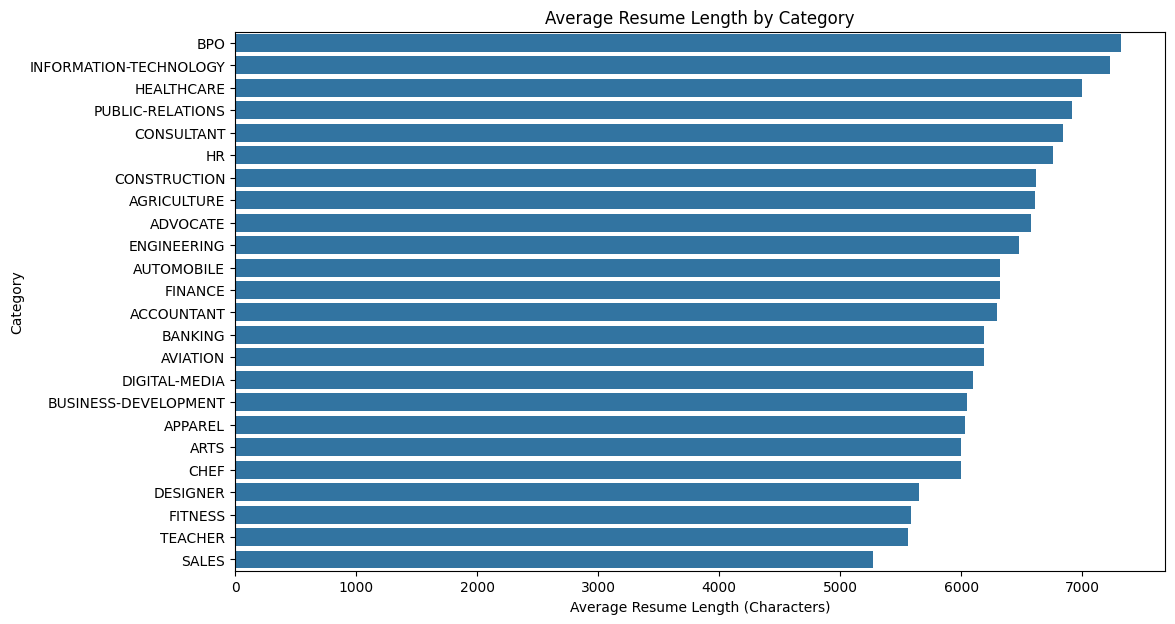

In [21]:
# Plot average resume length by category
plt.figure(figsize=(12, 7))

sns.barplot(
    x=avg_length.values,
    y=avg_length.index
)

plt.title("Average Resume Length by Category")
plt.xlabel("Average Resume Length (Characters)")
plt.ylabel("Category")

plt.show()

# 6. NLP Text Preprocessing

Text preprocessing prepares raw resume text for NLP analysis.

Before applying any cleaning steps, we first inspect a complete resume to understand the type of text, formatting, spacing, and noise present in the dataset.


In [22]:
# Display one complete raw resume
print(df['Resume_str'].iloc[0])

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss preve

## 6.1 Text Cleaning

Raw resume text may contain inconsistent capitalization, URLs, special characters, and unnecessary spaces.

A preprocessing function is created to standardize the text while preserving useful information required for resume–Job Description matching.


In [23]:
# Function to clean resume text
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove unwanted special characters
    text = re.sub(r'[^a-z0-9+#.\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [24]:
# Test the cleaning function
cleaned_sample = clean_text(df['Resume_str'].iloc[0])

print(cleaned_sample[:1500])

hr administrator marketing associate hr administrator summary dedicated customer service manager with 15+ years of experience in hospitality and customer service management. respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service. highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relations specialist accomplishments missouri dot supervisor training certification certified by ihg in customer loyalty and marketing by segment hilton worldwide general manager training certification accomplished trainer for cross server hospitality systems such as hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance assessment. experience hr administrator marke

## 6.2 Apply Text Cleaning to the Resume Dataset

After verifying the preprocessing function on a sample resume, the same cleaning process is applied to all resumes in the dataset.

The cleaned resume text is stored in a new column so that the original resume text remains available for reference.


In [25]:
# Apply text cleaning to all resumes
df['Clean_Resume'] = df['Resume_str'].apply(clean_text)

# Display cleaned data
df[['Resume_str', 'Clean_Resume']].head()

,Resume_str,Clean_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over 20 years experience i...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


## 6.3 Compare Original and Cleaned Resume Length

Text preprocessing removes unnecessary formatting and noise from the resume text.

To understand the effect of preprocessing, we compare the average length of the original resume text with the cleaned resume text.


In [26]:
# Calculate cleaned resume length
df['Clean_Resume_Length'] = df['Clean_Resume'].apply(len)

# Compare average lengths
print("Average Original Length:", df['Resume_Length'].mean())
print("Average Cleaned Length:", df['Clean_Resume_Length'].mean())

Average Original Length: 6295.3087761674715
Average Cleaned Length: 5799.877616747182


# 7. Feature Extraction using TF-IDF

Machine learning and similarity algorithms cannot directly process raw text. Therefore, the cleaned resume text needs to be converted into numerical features.

TF-IDF (Term Frequency–Inverse Document Frequency) is used to transform the resume text into numerical vectors. It gives higher importance to useful terms while reducing the importance of very common words.

These numerical representations will later be used to calculate similarity between resumes and Job Descriptions.


## 7.1 Import TfidfVectorizer

In [27]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

## 7.2 Create the TF-IDF Vectorizer

In [28]:
# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z0-9+#.]*\b'
)

## 7.3 Convert All Resumes into TF-IDF Features

In [29]:
# Convert cleaned resumes into TF-IDF features
tfidf_matrix = tfidf.fit_transform(df['Clean_Resume'])

In [30]:
# Check TF-IDF matrix shape
tfidf_matrix.shape

(2484, 39870)

## 7.4 Inspect TF-IDF Features

After fitting the TF-IDF vectorizer, we can inspect some of the terms included in the learned vocabulary.

These terms represent the textual features used to create numerical resume vectors for similarity comparison.


In [31]:
# Get TF-IDF feature names
feature_names = tfidf.get_feature_names_out()

# Display first 30 features
feature_names[:30]

array(['a+network', 'a.a', 'a.a.s', 'a.b', 'a.b.c', 'a.c', 'a.c.c.i',
       'a.d', 'a.d.d.i.e', 'a.g', 'a.i', 'a.k', 'a.m', 'a.m.e', 'a.n.s',
       'a.o', 'a.p', 'a.r', 'a.s', 'a.s.a', 'a.s.c.e', 'a.s.s.i.f', 'a.t',
       'a.v', 'a1', 'a10', 'a133', 'a18', 'a1l', 'a2'], dtype=object)

# 8. Resume–Job Description Matching using Cosine Similarity

After converting the resumes into TF-IDF numerical vectors, Cosine Similarity is used to measure how closely a resume matches a given Job Description.

Cosine Similarity compares the similarity between two text vectors. A higher score indicates that the resume contains more relevant terms and information related to the Job Description.

The similarity score will later be converted into a match score and used to rank candidates.


In [32]:
# Import cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

In [33]:
# Sample Job Description
job_description = """
We are looking for a Data Scientist with skills in Python, SQL, Pandas,
Machine Learning, Data Analysis, and Scikit-learn.
"""

In [34]:
# Clean the Job Description
clean_job_description = clean_text(job_description)

print(clean_job_description)

we are looking for a data scientist with skills in python sql pandas machine learning data analysis and scikit learn.


In [35]:
# Convert Job Description into TF-IDF features
jd_vector = tfidf.transform([clean_job_description])

In [36]:
# Calculate similarity between JD and all resumes
similarity_scores = cosine_similarity(jd_vector, tfidf_matrix)

In [37]:
similarity_scores.shape

(1, 2484)

In [38]:
# Convert similarity scores to 1D array
similarity_scores = similarity_scores.flatten()

In [39]:
similarity_scores.shape

(2484,)

In [40]:
# Display first 10 similarity scores
similarity_scores[:10]

array([0.01477349, 0.00064995, 0.0009805 , 0.00319248, 0.00458952,
       0.00598779, 0.00113947, 0.01738742, 0.02194091, 0.01345127])

In [41]:
# Find the highest similarity score
similarity_scores.max()

np.float64(0.22381377254008789)

In [42]:
# Find index of the best matching resume
best_match_index = similarity_scores.argmax()

best_match_index

np.int64(926)

In [43]:
# Display best matching resume information
print("Category:", df.iloc[best_match_index]['Category'])
print("Similarity Score:", similarity_scores[best_match_index])

Category: AGRICULTURE
Similarity Score: 0.22381377254008789


In [44]:
# Display the best matching resume text
print(df.iloc[best_match_index]['Resume_str'][:3000])

           SOFTWARE DEVELOPER         Professional Summary    Enthusiastic computer engineer eager to contribute to team success through hard work, attention to detail and excellent organizational skills. Technical professional with complete understanding of entire software development life cycle. Respectful self-motivator gifted at finding reliable solutions for software issues. Experienced in c#, python, HTML, SQL, node.js/javascript and working knowledge of Restful API design & implementations. Fluent in English and Turkish and accustomed to working with cross-cultural, global teams.      Skills          C#, HTML, CSS, JavaScript, 5 years of experience  SQL, 5 years of experience  Python, MatLab, MongoDB, Tableau, Node JS  Frameworks: .Net, Devexpress, TensorFlow, Keras, Scikit-learn, Pandas, NLTK.  Search Engine Optimization  Net  API  CSS  Clients  Database development  Designing  English  HTML      Image processing  JavaScript  Leadership  Marketing  MatLab  C#  Office  Windows  

In [45]:
# Get indices of top 5 matching resumes
top_5_indices = similarity_scores.argsort()[-5:][::-1]

top_5_indices

array([ 926, 1339, 1762, 1218, 1142])

In [46]:
# Display top 5 matching resumes
for index in top_5_indices:
    print("Index:", index)
    print("Category:", df.iloc[index]['Category'])
    print("Similarity Score:", similarity_scores[index])
    print("-" * 40)

Index: 926
Category: AGRICULTURE
Similarity Score: 0.22381377254008789
----------------------------------------
Index: 1339
Category: AUTOMOBILE
Similarity Score: 0.21564175039098932
----------------------------------------
Index: 1762
Category: ENGINEERING
Similarity Score: 0.19335998696697607
----------------------------------------
Index: 1218
Category: CONSULTANT
Similarity Score: 0.1765421390497592
----------------------------------------
Index: 1142
Category: CONSULTANT
Similarity Score: 0.1468021261847856
----------------------------------------


In [47]:
# Convert similarity scores into percentage
match_scores = similarity_scores * 100

In [48]:
# Display top 5 match scores
for index in top_5_indices:
    print("Index:", index)
    print("Match Score:", round(match_scores[index], 2), "%")
    print("-" * 30)

Index: 926
Match Score: 22.38 %
------------------------------
Index: 1339
Match Score: 21.56 %
------------------------------
Index: 1762
Match Score: 19.34 %
------------------------------
Index: 1218
Match Score: 17.65 %
------------------------------
Index: 1142
Match Score: 14.68 %
------------------------------


# 9. Candidate Ranking

After calculating the similarity scores between the Job Description and all resumes, candidates are ranked based on their match scores.

Resumes with higher match scores are placed at the top of the ranking, helping recruiters quickly identify the most relevant candidates.


In [49]:
# Create ranking dataframe
ranking_df = df.copy()

# Add match score column
ranking_df['Match_Score'] = match_scores

In [50]:
# Sort candidates by match score
ranking_df = ranking_df.sort_values(
    by='Match_Score',
    ascending=False
)

In [51]:
ranking_df[['Category', 'Match_Score']].head()

,Category,Match_Score
926,AGRICULTURE,22.381377
1339,AUTOMOBILE,21.564175
1762,ENGINEERING,19.335999
1218,CONSULTANT,17.654214
1142,CONSULTANT,14.680213


In [52]:
# Reset index after sorting
ranking_df = ranking_df.reset_index(drop=True)

In [53]:
# Display top 5 ranked candidates
ranking_df[['Category', 'Match_Score']].head()

,Category,Match_Score
0,AGRICULTURE,22.381377
1,AUTOMOBILE,21.564175
2,ENGINEERING,19.335999
3,CONSULTANT,17.654214
4,CONSULTANT,14.680213


In [54]:
# Create candidate rank
ranking_df['Rank'] = range(1, len(ranking_df) + 1)

In [55]:
# Display top 5 ranked candidates
ranking_df[['Rank', 'Category', 'Match_Score']].head()

,Rank,Category,Match_Score
0,1,AGRICULTURE,22.381377
1,2,AUTOMOBILE,21.564175
2,3,ENGINEERING,19.335999
3,4,CONSULTANT,17.654214
4,5,CONSULTANT,14.680213


In [56]:
# Round match scores to 2 decimal places
ranking_df['Match_Score'] = ranking_df['Match_Score'].round(2)

In [57]:
# Display top 5 candidates
ranking_df[['Rank', 'Category', 'Match_Score']].head()

,Rank,Category,Match_Score
0,1,AGRICULTURE,22.38
1,2,AUTOMOBILE,21.56
2,3,ENGINEERING,19.34
3,4,CONSULTANT,17.65
4,5,CONSULTANT,14.68


## 9.1 Skill Matching

In addition to the overall match score, relevant skills shared between the Job Description and each resume are identified.

Displaying matched skills makes the ranking results easier to understand and helps recruiters see why a candidate is relevant to the job.


In [58]:
# List of skills for matching
skills_list = [
    'python',
    'sql',
    'pandas',
    'numpy',
    'machine learning',
    'data analysis',
    'scikit learn',
    'tensorflow',
    'keras',
    'tableau',
    'power bi',
    'matlab',
    'nlp',
    'c++',
    'c#',
    'java',
    'javascript'
]

In [59]:
# Function to find matched skills
def get_matched_skills(resume_text, jd_text, skills):
    matched_skills = []

    for skill in skills:
        if skill in resume_text and skill in jd_text:
            matched_skills.append(skill)

    return matched_skills

In [60]:
# Test matched skills on the top candidate
matched_skills = get_matched_skills(
    ranking_df.iloc[0]['Clean_Resume'],
    clean_job_description,
    skills_list
)

matched_skills

['python', 'sql', 'pandas', 'scikit learn']

In [61]:
# Find matched skills for all candidates
ranking_df['Matched_Skills'] = ranking_df['Clean_Resume'].apply(
    lambda resume: get_matched_skills(
        resume,
        clean_job_description,
        skills_list
    )
)

In [62]:
# Display top 5 candidates with matched skills
ranking_df[
    ['Rank', 'Category', 'Match_Score', 'Matched_Skills']
].head()

,Rank,Category,Match_Score,Matched_Skills
0,1,AGRICULTURE,22.38,"[python, sql, pandas, scikit learn]"
1,2,AUTOMOBILE,21.56,"[python, sql, pandas, data analysis, scikit le..."
2,3,ENGINEERING,19.34,"[python, sql, pandas, machine learning, data a..."
3,4,CONSULTANT,17.65,"[python, sql, machine learning, data analysis]"
4,5,CONSULTANT,14.68,[sql]


# 10. Evaluation

The resume screening system is evaluated by checking whether resumes with relevant technical skills receive higher similarity scores than less relevant resumes.

Since this project focuses on resume–Job Description similarity and ranking rather than classification, the evaluation is based on ranking quality and relevance of the top matching resumes.


## 10.1 Check Match Score Distribution

In [63]:
# Check match score statistics
ranking_df['Match_Score'].describe()

,Match_Score
count,2484.000000
mean,1.291208
std,1.658303
min,0.000000
25%,0.320000
50%,0.810000
75%,1.680000
max,22.380000


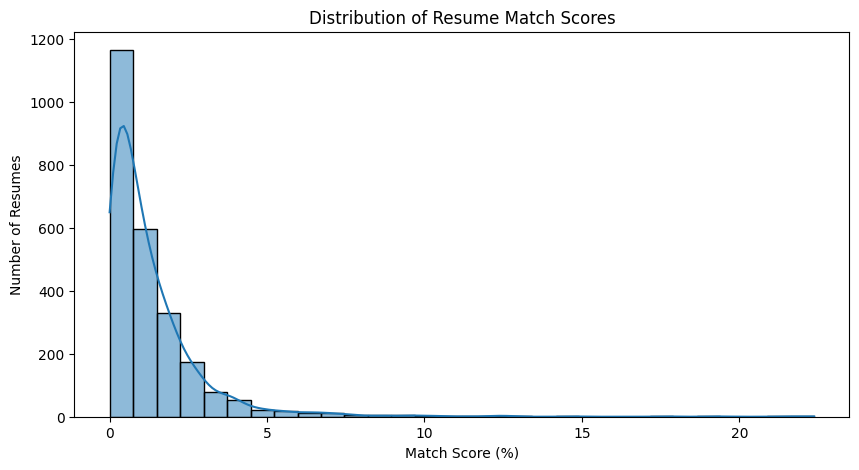

In [64]:
# Plot match score distribution
plt.figure(figsize=(10, 5))

sns.histplot(ranking_df['Match_Score'], bins=30, kde=True)

plt.title("Distribution of Resume Match Scores")
plt.xlabel("Match Score (%)")
plt.ylabel("Number of Resumes")

plt.show()

In [65]:
# Display top 10 ranked candidates
ranking_df[
    ['Rank', 'Category', 'Match_Score', 'Matched_Skills']
].head(10)

,Rank,Category,Match_Score,Matched_Skills
0,1,AGRICULTURE,22.38,"[python, sql, pandas, scikit learn]"
1,2,AUTOMOBILE,21.56,"[python, sql, pandas, data analysis, scikit le..."
2,3,ENGINEERING,19.34,"[python, sql, pandas, machine learning, data a..."
3,4,CONSULTANT,17.65,"[python, sql, machine learning, data analysis]"
4,5,CONSULTANT,14.68,[sql]
5,6,SALES,12.77,[sql]
6,7,DIGITAL-MEDIA,12.45,"[python, sql]"
7,8,BANKING,12.38,"[python, sql, machine learning]"
8,9,INFORMATION-TECHNOLOGY,12.13,"[python, sql, data analysis]"
9,10,INFORMATION-TECHNOLOGY,11.31,[sql]


In [66]:
# Count matched skills for each candidate
ranking_df['Matched_Skill_Count'] = ranking_df['Matched_Skills'].apply(len)

In [67]:
# Display top 10 candidates with matched skill count
ranking_df[
    ['Rank', 'Category', 'Match_Score', 'Matched_Skill_Count']
].head(10)

,Rank,Category,Match_Score,Matched_Skill_Count
0,1,AGRICULTURE,22.38,4
1,2,AUTOMOBILE,21.56,5
2,3,ENGINEERING,19.34,5
3,4,CONSULTANT,17.65,4
4,5,CONSULTANT,14.68,1
5,6,SALES,12.77,1
6,7,DIGITAL-MEDIA,12.45,2
7,8,BANKING,12.38,3
8,9,INFORMATION-TECHNOLOGY,12.13,3
9,10,INFORMATION-TECHNOLOGY,11.31,1


In [68]:
# Calculate correlation
ranking_df[
    ['Match_Score', 'Matched_Skill_Count']
].corr()

,Match_Score,Matched_Skill_Count
Match_Score,1.000000,0.692918
Matched_Skill_Count,0.692918,1.000000


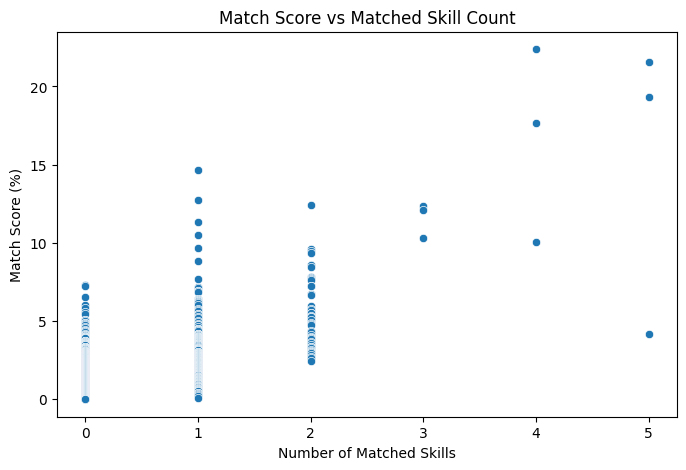

In [69]:
# Plot match score vs matched skill count
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Matched_Skill_Count',
    y='Match_Score',
    data=ranking_df
)

plt.title("Match Score vs Matched Skill Count")
plt.xlabel("Number of Matched Skills")
plt.ylabel("Match Score (%)")

plt.show()

## 10.2 Controlled Resume Matching Test

To further evaluate the matching system, controlled sample resumes with different levels of relevance to the same Job Description are compared.

Three test cases are used:

* **Strong Match:** Contains several skills directly relevant to the Job Description.
* **Partial Match:** Contains only some relevant skills.
* **Mismatch:** Contains skills and experience unrelated to the Job Description.

A correctly functioning matching system should assign the highest score to the strong match, followed by the partial match, and the lowest score to the mismatch.


In [70]:
# Controlled test resumes

strong_match_resume = """
Data Scientist with experience in Python, SQL, Pandas,
Machine Learning, Data Analysis and Scikit-learn.
"""

partial_match_resume = """
Software professional with experience in Python, SQL and Excel.
"""

mismatch_resume = """
Chef with experience in cooking, food preparation,
kitchen management and restaurant operations.
"""

In [71]:
# Clean controlled test resumes
strong_clean = clean_text(strong_match_resume)
partial_clean = clean_text(partial_match_resume)
mismatch_clean = clean_text(mismatch_resume)

In [72]:
# Convert controlled resumes into TF-IDF vectors
strong_vector = tfidf.transform([strong_clean])
partial_vector = tfidf.transform([partial_clean])
mismatch_vector = tfidf.transform([mismatch_clean])

In [73]:
# Calculate similarity scores for controlled resumes
strong_score = cosine_similarity(jd_vector, strong_vector)[0][0]
partial_score = cosine_similarity(jd_vector, partial_vector)[0][0]
mismatch_score = cosine_similarity(jd_vector, mismatch_vector)[0][0]

In [74]:
# Display controlled test results
print("Strong Match:", round(strong_score * 100, 2), "%")
print("Partial Match:", round(partial_score * 100, 2), "%")
print("Mismatch:", round(mismatch_score * 100, 2), "%")

Strong Match: 96.62 %
Partial Match: 35.24 %
Mismatch: 0.0 %


In [75]:
# Create controlled evaluation results
evaluation_df = pd.DataFrame({
    'Test_Case': ['Strong Match', 'Partial Match', 'Mismatch'],
    'Match_Score': [
        round(strong_score * 100, 2),
        round(partial_score * 100, 2),
        round(mismatch_score * 100, 2)
    ]
})

evaluation_df

,Test_Case,Match_Score
0,Strong Match,96.62
1,Partial Match,35.24
2,Mismatch,0.00


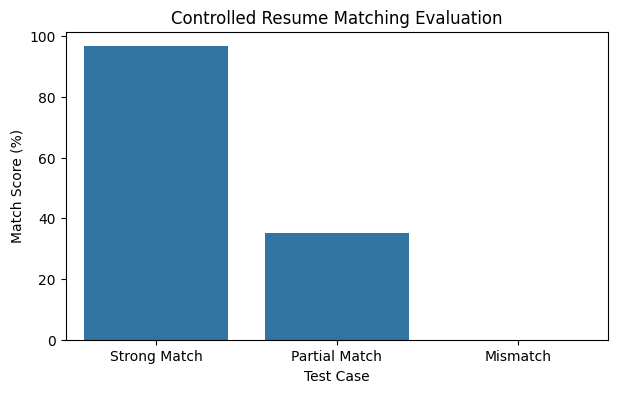

In [76]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x='Test_Case',
    y='Match_Score',
    data=evaluation_df
)

plt.title("Controlled Resume Matching Evaluation")
plt.xlabel("Test Case")
plt.ylabel("Match Score (%)")

plt.show()

### Controlled Test Result

The controlled evaluation shows that the system successfully distinguishes resumes based on their relevance to the Job Description.

- The **Strong Match** resume achieved the highest similarity score.
- The **Partial Match** resume received a moderate similarity score.
- The **Mismatch** resume received almost no similarity score.

This demonstrates that the TF-IDF and cosine similarity approach can effectively identify and rank resumes according to their textual relevance to a given Job Description.

## 10.3 Top-K Ranking Evaluation

Top-K evaluation is used to examine the quality of the highest-ranked candidates produced by the resume screening system.

For this evaluation, the top 10 ranked resumes are analyzed based on their match scores and matched skills.

This helps determine whether the ranking system places resumes with relevant Job Description skills near the top of the candidate list.

In [77]:
# Select top 10 ranked candidates
top_10 = ranking_df.head(10)

top_10[['Rank', 'Category', 'Match_Score', 'Matched_Skill_Count', 'Matched_Skills']]

,Rank,Category,Match_Score,Matched_Skill_Count,Matched_Skills
0,1,AGRICULTURE,22.38,4,"[python, sql, pandas, scikit learn]"
1,2,AUTOMOBILE,21.56,5,"[python, sql, pandas, data analysis, scikit le..."
2,3,ENGINEERING,19.34,5,"[python, sql, pandas, machine learning, data a..."
3,4,CONSULTANT,17.65,4,"[python, sql, machine learning, data analysis]"
4,5,CONSULTANT,14.68,1,[sql]
5,6,SALES,12.77,1,[sql]
6,7,DIGITAL-MEDIA,12.45,2,"[python, sql]"
7,8,BANKING,12.38,3,"[python, sql, machine learning]"
8,9,INFORMATION-TECHNOLOGY,12.13,3,"[python, sql, data analysis]"
9,10,INFORMATION-TECHNOLOGY,11.31,1,[sql]


In [78]:
# Average matched skills among top 10 candidates
top_10_avg_skills = top_10['Matched_Skill_Count'].mean()

print("Average Matched Skills in Top 10:", round(top_10_avg_skills, 2))

Average Matched Skills in Top 10: 2.9


In [79]:
# Average matched skills across all resumes
overall_avg_skills = ranking_df['Matched_Skill_Count'].mean()

print("Average Matched Skills in All Resumes:", round(overall_avg_skills, 2))

Average Matched Skills in All Resumes: 0.15


In [80]:
# Compare top 10 with overall resumes
improvement_ratio = top_10_avg_skills / overall_avg_skills

print("Top 10 Skill Match Ratio:", round(improvement_ratio, 2), "times")

Top 10 Skill Match Ratio: 19.11 times


### Top-K Evaluation Result

The Top 10 ranked candidates contained an average of **2.9 matched skills**, while the complete resume dataset contained an average of only **0.15 matched skills** per resume.

This means that the Top 10 candidates had approximately **19.11 times more matched Job Description skills** than the overall dataset average.

This result indicates that the ranking system successfully places resumes containing more relevant Job Description skills toward the top of the candidate list.

# 11. Deployment Preparation

The trained NLP matching pipeline will now be prepared for deployment.

The deployment system will allow a recruiter to:

- Enter or paste a Job Description.
- Upload candidate resumes.
- Clean and preprocess the resume text.
- Convert the Job Description and resumes into TF-IDF features.
- Calculate cosine similarity scores.
- Identify matched skills.
- Rank candidates based on their relevance to the Job Description.

The same NLP preprocessing and matching logic developed in this notebook will be reused in the deployed application.

## 11.1 Resume Matching Function

A reusable function is created to combine the preprocessing, TF-IDF transformation, cosine similarity calculation, skill matching, and candidate ranking steps.

This function will later be used by the deployed application to process new resumes and a Job Description.

In [81]:
# Reusable resume matching function
def rank_resumes(job_description, resumes):
    # Clean Job Description
    clean_jd = clean_text(job_description)

    # Clean resumes
    clean_resumes = [clean_text(resume) for resume in resumes]

    # Convert text into TF-IDF vectors
    resume_vectors = tfidf.transform(clean_resumes)
    jd_vector = tfidf.transform([clean_jd])

    # Calculate similarity scores
    scores = cosine_similarity(jd_vector, resume_vectors).flatten() * 100

    # Create results
    results = []

    for i, resume in enumerate(clean_resumes):
        matched_skills = get_matched_skills(
            resume,
            clean_jd,
            skills_list
        )

        results.append({
            'Resume_Number': i + 1,
            'Match_Score': round(scores[i], 2),
            'Matched_Skills': matched_skills,
            'Matched_Skill_Count': len(matched_skills)
        })

    # Convert to DataFrame and rank candidates
    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by='Match_Score',
        ascending=False
    ).reset_index(drop=True)

    results_df['Rank'] = range(1, len(results_df) + 1)

    return results_df

In [82]:
# Test reusable ranking function
test_resumes = [
    strong_match_resume,
    partial_match_resume,
    mismatch_resume
]

test_results = rank_resumes(job_description, test_resumes)

test_results

,Resume_Number,Match_Score,Matched_Skills,Matched_Skill_Count,Rank
0,1,96.62,"[python, sql, pandas, machine learning, data a...",6,1
1,2,35.24,"[python, sql]",2,2
2,3,0.00,[],0,3


### Resume Matching Function Test

The reusable ranking function was tested using controlled resumes with strong, partial, and unrelated relevance to the Job Description.

The function correctly ranked the strong match first, the partial match second, and the mismatch last.

This confirms that the complete preprocessing, TF-IDF transformation, cosine similarity, skill matching, and ranking pipeline works correctly and is ready to be integrated into the deployment application.

In [83]:
import joblib

In [84]:
# Save fitted TF-IDF vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

## 11.2 Save TF-IDF Vectorizer

The fitted TF-IDF vectorizer is saved using Joblib so that the deployed application can reuse the same vocabulary and feature representation used during development.

This prevents the application from fitting a new vectorizer every time it runs and ensures consistency between the notebook and the deployed system.